# Библиотеки

In [43]:
from itertools import combinations

import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg

import seaborn as sns

## 9.14 Сравнение парных\связанных групп: 2 группы, параметрика

In [2]:
d = pd.read_spss('./data/SPSS16.sav')

In [3]:
d = d.set_index('Анкета')

In [4]:
d['LoyDiff'] = d['ЛояльностьСергеев2016'] - d['ЛояльностьСергеев2015']
d['MotDiff'] = d['МотивацияВрум2016'] - d['МотивацияВрум2015']

In [5]:
d.head()

,МотивацияВрум2015,ЛояльностьСергеев2015,МотивацияВрум2016,ЛояльностьСергеев2016,LoyDiff,MotDiff
Анкета,,,,,,
1235.0,40.0,61.0,46.0,67.0,6.0,6.0
1236.0,61.0,59.0,67.0,66.0,7.0,6.0
1237.0,68.0,28.0,73.0,38.0,10.0,5.0
1238.0,27.0,26.0,32.0,33.0,7.0,5.0
1239.0,63.0,28.0,71.0,38.0,10.0,8.0


In [6]:
pg.normality(data=d, method='normaltest')

,W,pval,normal
МотивацияВрум2015,5498.775123,0.000000e+00,False
ЛояльностьСергеев2015,4981.916430,0.000000e+00,False
МотивацияВрум2016,778.039814,1.124090e-169,False
ЛояльностьСергеев2016,3282.662524,0.000000e+00,False
LoyDiff,3604.874150,0.000000e+00,False
MotDiff,3825.121479,0.000000e+00,False


In [7]:
d.describe().T

,count,mean,std,min,25%,50%,75%,max
МотивацияВрум2015,5201.0,51.472025,15.763445,25.0,38.0,52.0,65.0,78.0
ЛояльностьСергеев2015,5201.0,39.815612,14.642904,15.0,27.0,40.0,53.0,65.0
МотивацияВрум2016,5120.0,59.383398,16.542276,8.0,45.0,60.0,74.0,90.0
ЛояльностьСергеев2016,5117.0,47.660348,14.601654,20.0,35.0,48.0,60.0,75.0
LoyDiff,5117.0,7.501075,1.938925,-19.0,6.0,7.0,9.0,48.0
MotDiff,5120.0,7.700586,4.883883,-28.0,6.0,8.0,10.0,27.0


In [8]:
pg.ttest(x=d['МотивацияВрум2016'], y=d['МотивацияВрум2015'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,112.821921,5119,two-sided,0.0,"[7.57, 7.83]",0.476828,inf,NaN


In [9]:
pg.ttest(x=d['ЛояльностьСергеев2016'], y=d['ЛояльностьСергеев2015'], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,276.738896,5116,two-sided,0.0,"[7.45, 7.55]",0.515335,inf,NaN


## 9.15 Сравнение парных\связанных групп: 2 группы, непараметрика

In [10]:
pg.wilcoxon(x=d['МотивацияВрум2016'], y=d['МотивацияВрум2015'])

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,816450.5,two-sided,0.0,0.875444,0.630392


In [11]:
pg.wilcoxon(x=d['ЛояльностьСергеев2016'], y=d['ЛояльностьСергеев2015'])

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,8117.5,two-sided,0.0,0.99876,0.637763


## 9.16 Сравнение парных групп: более 2-х групп, параметрика, с пост-хок

In [12]:
d = pd.read_spss('./data/SPSS17.sav')

In [13]:
d = d.set_index('Анкета')

In [14]:
d.describe().T

,count,mean,std,min,25%,50%,75%,max
МотивацияВрум2015,5076.0,51.660165,15.744517,25.0,38.0,52.0,66.0,78.0
ЛояльностьСергеев2015,5076.0,40.341411,14.424059,15.0,28.0,40.0,53.0,65.0
МотивацияВрум2016,5076.0,59.349685,16.544696,8.0,45.0,60.0,74.0,90.0
ЛояльностьСергеев2016,5073.0,47.861620,14.501787,20.0,35.0,48.0,60.0,75.0
МотивацияВрум2017,5076.0,59.491923,16.647837,8.0,45.0,60.0,74.0,99.0
ЛояльностьСергеев2017,5073.0,47.862803,14.501214,20.0,35.0,48.0,60.0,75.0


In [15]:
d = \
(d
 .assign(
     LoyDiff = lambda df: df['ЛояльностьСергеев2016'] - df['ЛояльностьСергеев2015'],
     MotDiff = lambda df: df['МотивацияВрум2016'] - df['МотивацияВрум2015'],
     LoyDiff2 = lambda df: df['ЛояльностьСергеев2017'] - df['ЛояльностьСергеев2015'],
     MotDiff2 = lambda df: df['МотивацияВрум2017'] - df['МотивацияВрум2015'],
     LoyDiff3 = lambda df: df['ЛояльностьСергеев2017'] - df['ЛояльностьСергеев2016'],
     MotDiff3 = lambda df: df['МотивацияВрум2017'] - df['МотивацияВрум2016']
 )
)

In [16]:
dl_1 = (
    d.reset_index()  # Анкета из индекса становится столбцом
    .melt(id_vars="Анкета", var_name="Показатель", value_name="Значение") # Мельтируем в отдельные столбцы названия показателей и значения
   )

In [17]:
dl_1['Год'] = dl_1['Показатель'].str[-4:] # последние 4 символа
dl_1['Метрика'] = dl_1['Показатель'].str[:-4] # все, кроме последних 4 символов

In [18]:
dl = dl_1.pivot_table(index=['Анкета', 'Год'], columns='Метрика', values='Значение').reset_index()

In [19]:
dl

Метрика,Анкета,Год,Loy,LoyD,Mot,MotD,ЛояльностьСергеев,МотивацияВрум
0,1235,2015,NaN,NaN,NaN,NaN,61.0,40.0
1,1235,2016,NaN,NaN,NaN,NaN,67.0,46.0
2,1235,2017,NaN,NaN,NaN,NaN,66.0,49.0
3,1235,Diff,6.0,NaN,6.0,NaN,NaN,NaN
4,1235,iff2,NaN,5.0,NaN,9.0,NaN,NaN
...,...,...,...,...,...,...,...,...
30451,6435,2016,NaN,NaN,NaN,NaN,31.0,47.0
30452,6435,2017,NaN,NaN,NaN,NaN,31.0,47.0
30453,6435,Diff,6.0,NaN,9.0,NaN,NaN,NaN
30454,6435,iff2,NaN,6.0,NaN,9.0,NaN,NaN


In [20]:
pg.rm_anova(data=dl, dv='ЛояльностьСергеев',within='Год', subject='Анкета') #для Лояльности

,Source,ddof1,ddof2,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,Год,2,10144,75444.352555,0.0,0.0,0.056434,0.504131,False,0.016388,0.0


In [21]:
pg.rm_anova(data=dl, dv='МотивацияВрум',within='Год', subject='Анкета') #для Мотивации

,Source,ddof1,ddof2,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,Год,2,10150,11441.086552,0.0,0.0,0.047882,0.576806,False,0.266315,0.0


In [22]:
pg.pairwise_tests(data=dl, dv='ЛояльностьСергеев',within='Год', subject='Анкета', padjust="bonf") #для лояльности

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,Год,2015,2016,True,True,-275.755965,5072.0,two-sided,0.000000,0.0,bonf,inf,-0.519145
1,Год,2015,2017,True,True,-274.351046,5072.0,two-sided,0.000000,0.0,bonf,inf,-0.519237
2,Год,2016,2017,True,True,-0.582734,5072.0,two-sided,0.560099,1.0,bonf,0.019,-0.000082


In [23]:
pg.pairwise_tests(data=dl, dv='МотивацияВрум',within='Год', subject='Анкета', padjust="bonf") #для мотивации

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,Год,2015,2016,True,True,-111.829588,5075.0,two-sided,0.000000e+00,0.000000e+00,bonf,inf,-0.476109
1,Год,2015,2017,True,True,-107.758109,5075.0,two-sided,0.000000e+00,0.000000e+00,bonf,inf,-0.483332
2,Год,2016,2017,True,True,-6.233887,5075.0,two-sided,4.918098e-10,1.475429e-09,bonf,3.992e+06,-0.008570


In [24]:
pg.rm_anova(data=d[['ЛояльностьСергеев2015', 'ЛояльностьСергеев2016', 'ЛояльностьСергеев2017']])

,Source,ddof1,ddof2,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,Within,2,10144,75444.352555,0.0,0.0,0.056434,0.504131,False,0.016388,0.0


## 9.18 Сравнение парных групп: более 2-х групп,непараметрика,с пост-хок

In [25]:
dl.head(3)

Метрика,Анкета,Год,Loy,LoyD,Mot,MotD,ЛояльностьСергеев,МотивацияВрум
0,1235,2015,NaN,NaN,NaN,NaN,61.0,40.0
1,1235,2016,NaN,NaN,NaN,NaN,67.0,46.0
2,1235,2017,NaN,NaN,NaN,NaN,66.0,49.0


In [26]:
pg.friedman(data=dl, dv='ЛояльностьСергеев', within='Год', subject='Анкета')

,Source,W,ddof1,Q,p-unc
Friedman,Год,0.996852,2,10114.057207,0.0


In [27]:
pg.pairwise_tests(data=dl, dv='ЛояльностьСергеев', within='Год', subject='Анкета', padjust="bonf", parametric=False)

,Contrast,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Год,2015,2016,True,False,8041.0,two-sided,0.000000,0.0,bonf,-0.519145
1,Год,2015,2017,True,False,8041.5,two-sided,0.000000,0.0,bonf,-0.519237
2,Год,2016,2017,True,False,129.5,two-sided,0.561987,1.0,bonf,-0.000082


In [28]:
pg.friedman(data=dl, dv='МотивацияВрум', within='Год', subject='Анкета')

,Source,W,ddof1,Q,p-unc
Friedman,Год,0.836429,2,8491.427348,0.0


In [29]:
pg.pairwise_tests(data=dl, dv='МотивацияВрум', within='Год', subject='Анкета', padjust="bonf", parametric=False)

,Contrast,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Год,2015,2016,True,False,809454.5,two-sided,0.000000e+00,0.000000e+00,bonf,-0.476109
1,Год,2015,2017,True,False,799258.0,two-sided,0.000000e+00,0.000000e+00,bonf,-0.483332
2,Год,2016,2017,True,False,29593.0,two-sided,5.868708e-10,1.760613e-09,bonf,-0.008570


## 9.20 Таблицы сопряженности: МакНемар для категор. признаков в завис.

In [32]:
d['Loyal2015'] = (d['ЛояльностьСергеев2015'] > 40).astype(int)
d['Loyal2016'] = (d['ЛояльностьСергеев2016'] > 40).astype(int)
d['Loyal2017'] = (d['ЛояльностьСергеев2017'] > 40).astype(int)

In [38]:
a, b = pg.chi2_mcnemar(data=d, x='Loyal2015', y='Loyal2016') # Сравниваем  Лояльность 2015 с 2016

print(a)
b

Loyal2016     0     1
Loyal2015            
0          1804   749
1             1  2522


,chi2,dof,p-approx,p-exact
mcnemar,744.012,1,8.042948e-164,2.536140e-223


In [40]:
a, b = pg.chi2_mcnemar(data=d, x='Loyal2016', y='Loyal2017') # Сравниваем  Лояльность 2015 с 2016

print(a)
b

Loyal2017     0     1
Loyal2016            
0          1804     1
1             0  3271


,chi2,dof,p-approx,p-exact
mcnemar,0.0,1,1.0,1


In [44]:
d.head()

,МотивацияВрум2015,ЛояльностьСергеев2015,МотивацияВрум2016,ЛояльностьСергеев2016,МотивацияВрум2017,ЛояльностьСергеев2017,LoyDiff,MotDiff,LoyDiff2,MotDiff2,LoyDiff3,MotDiff3,Loyal2015,Loyal2016,Loyal2017
Анкета,,,,,,,,,,,,,,,
1235,40.0,61.0,46.0,67.0,49.0,66.0,6.0,6.0,5.0,9.0,-1.0,3.0,1,1,1
1236,61.0,59.0,67.0,66.0,62.0,69.0,7.0,6.0,10.0,1.0,3.0,-5.0,1,1,1
1237,68.0,28.0,73.0,38.0,67.0,41.0,10.0,5.0,13.0,-1.0,3.0,-6.0,0,0,1
1238,27.0,26.0,32.0,33.0,39.0,33.0,7.0,5.0,7.0,12.0,0.0,7.0,0,0,0
1239,63.0,28.0,71.0,38.0,77.0,36.0,10.0,8.0,8.0,14.0,-2.0,6.0,0,0,0


In [45]:
pairs = list(combinations(['Loyal2015', 'Loyal2016', 'Loyal2017'], 2)) # Генерируем список все возможных комбинаций столбцов попарно (по  2), в результате тут будет список из парных кортежей

results_list = [] # Создаем пустой список, который наполним результатами теста МакНемара под каждую пару

for x, y in pairs: # Запуск цикла по всем парам переменных,  в pairs у нас уже есть список пар  в виде кортежей
    cross, res = pg.chi2_mcnemar(d, x=x, y=y)  # поскольку тест МакНемара возвращает два DataFrame (кросстаб и Хи2 со значим.) раскладываем их на две переменные
    results_list.append({
        'pair': f'{x}_vs_{y}',
        'chi2': res['chi2'].iloc[0],
        'p_approx': res['p-approx'].iloc[0],
        'p_exact': res['p-exact'].iloc[0]
    }) # это словарик с ключами, в который мы забираем нужные столбцы из res и их значения - добавляя их в пустой список results_list
rd = pd.DataFrame(results_list) # записанные нужные нам результаты запихиваем в датафрейм

rd

,pair,chi2,p_approx,p_exact
0,Loyal2015_vs_Loyal2016,744.012000,8.042948e-164,2.536140e-223
1,Loyal2015_vs_Loyal2017,745.011984,4.875067e-164,1.269758e-223
2,Loyal2016_vs_Loyal2017,0.000000,1.000000e+00,1.000000e+00


### Q-Кокрана

In [46]:
pg.cochran(data=d[['Loyal2015','Loyal2016','Loyal2017']].astype(int)) # .astype(int) нужен если у Вас бинарная природа в True\False, чтобы преобразовать в 1 и 0

,Source,dof,Q,p-unc
cochran,Within,2,1492.018642,0.0


In [47]:
dl['Loyal'] = (dl['ЛояльностьСергеев'] > 40).astype(int) # Перекодируем в бинарку - и превращаем True\False  в 1 и 0

In [48]:
pg.cochran(data=dl, dv='Loyal', within='Год', subject='Анкета') # тест Кокрана под long-датафрейм

,Source,dof,Q,p-unc
cochran,Год,5,14709.645993,0.0


## 9.21 Разговоры о красивом

In [55]:
d.describe()

,МотивацияВрум2015,ЛояльностьСергеев2015,МотивацияВрум2016,ЛояльностьСергеев2016,МотивацияВрум2017,ЛояльностьСергеев2017,LoyDiff,MotDiff,LoyDiff2,MotDiff2,LoyDiff3,MotDiff3,Loyal2015,Loyal2016,Loyal2017
count,5076.000000,5076.000000,5076.000000,5073.000000,5076.000000,5073.000000,5073.000000,5076.000000,5073.000000,5076.000000,5073.000000,5076.000000,5076.000000,5076.000000,5076.000000
mean,51.660165,40.341411,59.349685,47.861620,59.491923,47.862803,7.507589,7.689519,7.508772,7.831757,0.001183,0.142238,0.497045,0.644405,0.644602
std,15.744517,14.424059,16.544696,14.501787,16.647837,14.501214,1.939135,4.898953,1.949372,5.178096,0.144560,1.625614,0.500041,0.478740,0.478681
min,25.000000,15.000000,8.000000,20.000000,8.000000,20.000000,-19.000000,-28.000000,-19.000000,-26.000000,-3.000000,-7.000000,0.000000,0.000000,0.000000
25%,38.000000,28.000000,45.000000,35.000000,45.000000,35.000000,6.000000,6.000000,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,52.000000,40.000000,60.000000,48.000000,60.000000,48.000000,7.000000,8.000000,7.000000,8.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,66.000000,53.000000,74.000000,60.000000,74.000000,60.000000,9.000000,10.000000,9.000000,11.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,78.000000,65.000000,90.000000,75.000000,99.000000,75.000000,48.000000,27.000000,48.000000,27.000000,3.000000,10.000000,1.000000,1.000000,1.000000


In [56]:
d.fillna(d.mean(numeric_only=True), inplace=True)

C:\pyenvs\da-python\Lib\site-packages\pingouin\plotting.py:816: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.stripplot(
C:\pyenvs\da-python\Lib\site-packages\pingouin\plotting.py:867: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(["Y", "X"], size=15)


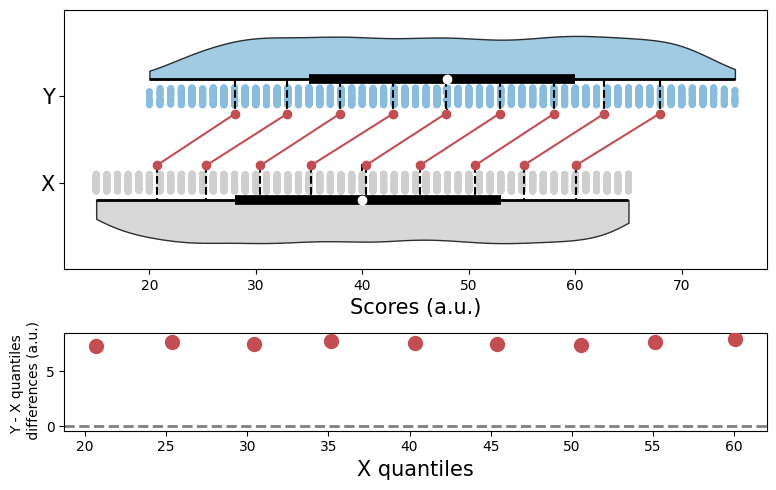

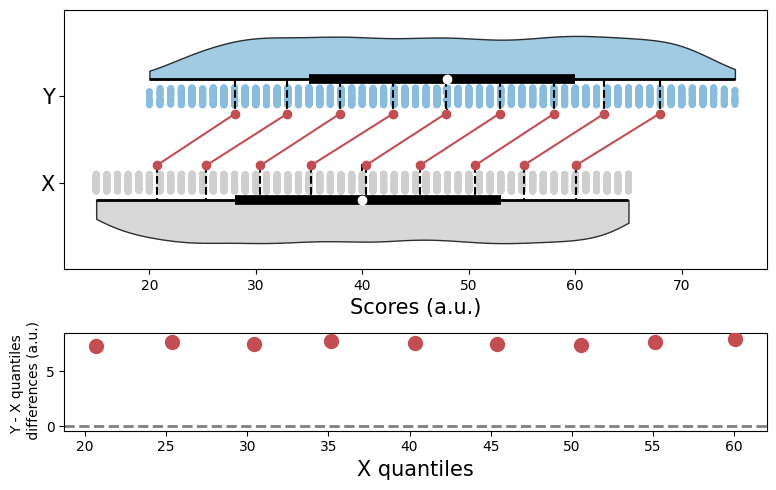

In [59]:
pg.plot_shift(x=d['ЛояльностьСергеев2015'], y=d['ЛояльностьСергеев2016'], paired=True)

### Задание: Испытаем "пингвиновую" красоту: боксплот с поинтплотом

In [62]:
dl['ЛояльностьСергеев'] = dl['ЛояльностьСергеев'].fillna(dl.groupby('Год')['ЛояльностьСергеев'].transform('mean'))

C:\pyenvs\da-python\Lib\site-packages\pingouin\plotting.py:573: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["wthn"] = data[within].replace({_ordr: i for i, _ordr in enumerate(order)})


KeyboardInterrupt: 

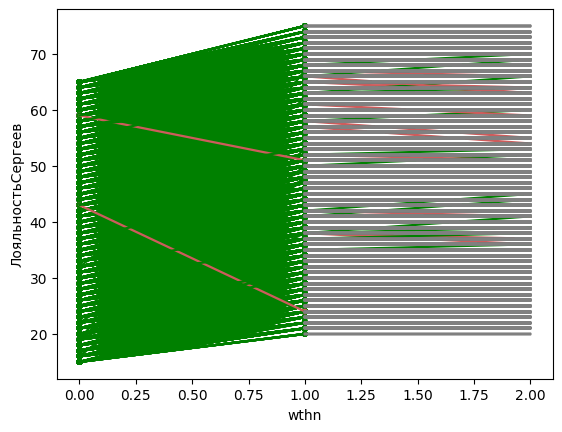

In [64]:
pg.plot_paired(data=dl, dv='ЛояльностьСергеев', within='Год', subject='Анкета')

### BlandAltman

In [65]:
d = pg.read_dataset('blandaltman')

<Axes: xlabel='Mean of A and B', ylabel='A - B'>

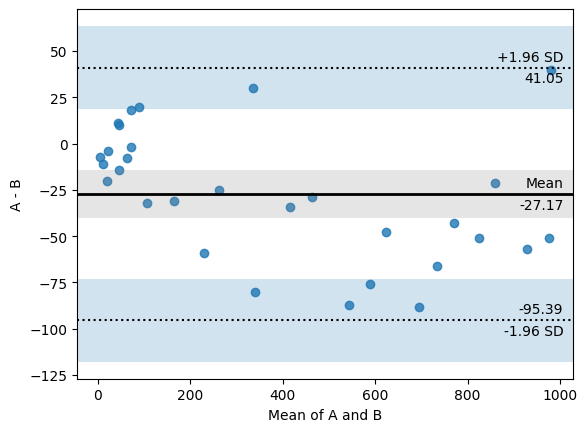

In [66]:
pg.plot_blandaltman(d['A'], d['B'])